In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.getcwd()

df = pd.read_csv("data/Salary_dataset.csv")

df.head()


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [3]:
print("Shape: ", df.shape)
print(df.head())

X = df[['YearsExperience']].values  # (n,1)
y = df[['Salary']].values           # (n,1)

X = X.astype(float)
y = y.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)


Shape:  (30, 3)
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0
X shape: (30, 1)
y shape: (30, 1)


In [4]:
def predict(X, w, b):
    return w*X + b

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)


In [5]:
loss_history = []

w = 0
b = 0
lr = 0.01
epochs = 1000
n = len(X)

for epoch in range(epochs):
    y_pred = predict(X, w, b)
    
    dw = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)

    w = w - lr * dw
    b = b - lr * db

    loss = mse(y, y_pred)
    loss_history.append(loss)

print("Final w:", w)
print("Final b:", b)
print("Final Loss:", loss_history[-1])


Final w: 9504.801321957242
Final b: 24474.557566113308
Final Loss: 31300502.429962


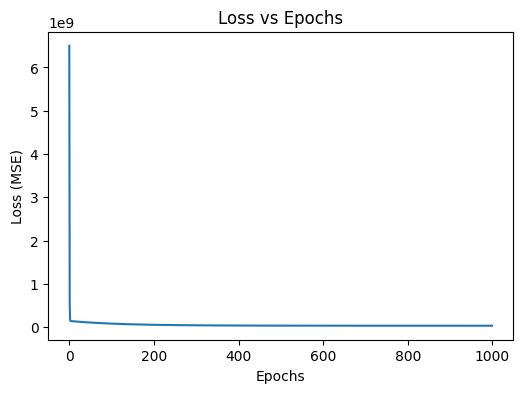

In [6]:
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epochs")
plt.show()


In [7]:
def train_lr(lr, epochs=1000):
    w = 0
    b = 0
    n = len(X)
    losses = []

    for epoch in range(epochs):
        y_pred = predict(X, w, b)

        dw = (-2/n) * np.sum(X * (y - y_pred))
        db = (-2/n) * np.sum(y - y_pred)

        w = w - lr * dw
        b = b - lr * db

        losses.append(mse(y, y_pred))
    
    return w, b, losses


In [8]:
lr_list = [0.1, 0.01, 0.001]
results = {}

for lr in lr_list:
    w, b, loss_curve = train_lr(lr)
    results[lr] = loss_curve
    print(f"LR={lr} | Final Loss={loss_curve[-1]}")


LR=0.1 | Final Loss=nan
LR=0.01 | Final Loss=31300502.429962
LR=0.001 | Final Loss=79973622.24267474


c:\Users\vaish\OneDrive\Desktop\creativearc\Creative-Arc-Internship\week3\week3_linear_regression\venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\vaish\AppData\Local\Temp\ipykernel_26316\1403812046.py:5: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred)**2)
c:\Users\vaish\OneDrive\Desktop\creativearc\Creative-Arc-Internship\week3\week3_linear_regression\venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\vaish\AppData\Local\Temp\ipykernel_26316\3113306911.py:13: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - lr * dw


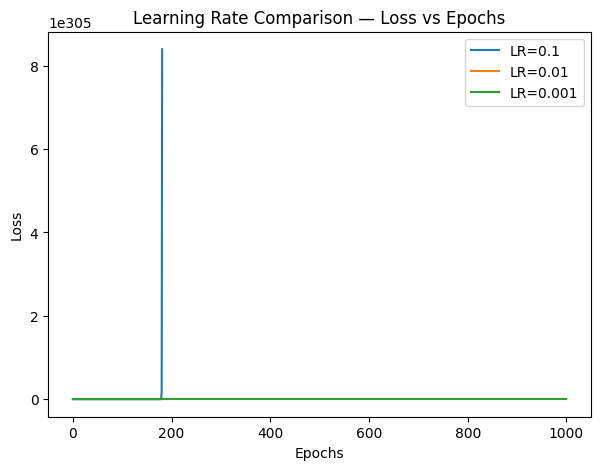

In [9]:
plt.figure(figsize=(7,5))

for lr in lr_list:
    plt.plot(results[lr], label=f"LR={lr}")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison — Loss vs Epochs")
plt.legend()
plt.show()


In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("Sklearn Coefficient:", model.coef_)
print("Sklearn Intercept:", model.intercept_)


Sklearn Coefficient: [[9449.96232146]]
Sklearn Intercept: [24848.20396652]


In [11]:
test_exp = 5
print("Scratch Prediction:", predict(np.array([[test_exp]]), w, b)[0][0])
print("Sklearn Prediction:", model.predict([[test_exp]])[0][0])


Scratch Prediction: 68045.60500422603
Sklearn Prediction: 72098.01557379858
